In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
try:
    df = pd.read_csv('/content/wine.csv')
    print('Dataset loaded from /content/wine.csv')

except FileNotFoundError:
    wine = load_wine(as_frame=True)
    df = wine.frame.copy()

    df['WineClass'] = df['target'].map({
        0: 'class_0',
        1: 'class_1',
        2: 'class_2'
    })

    df.drop(columns=['target'], inplace=True)

    print('Built-in sklearn Wine dataset loaded as fallback')

df.head()

Built-in sklearn Wine dataset loaded as fallback


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WineClass
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


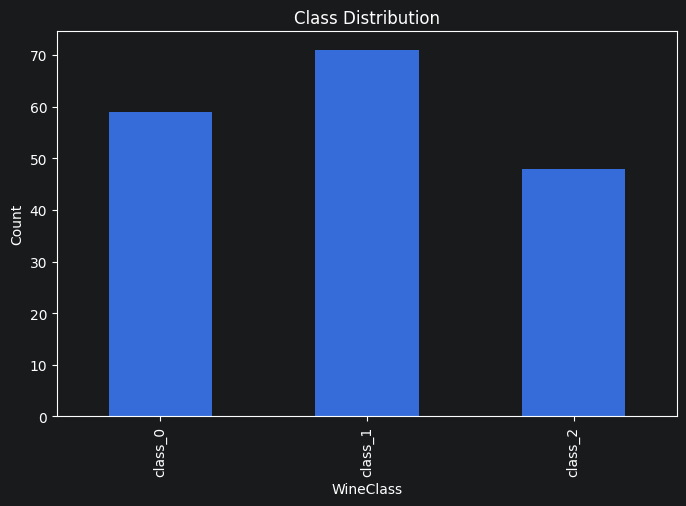

In [3]:
plt.figure(figsize=(8, 5))

df['WineClass'].value_counts().sort_index().plot(kind='bar')

plt.title('Class Distribution')
plt.xlabel('WineClass')
plt.ylabel('Count')

plt.show()

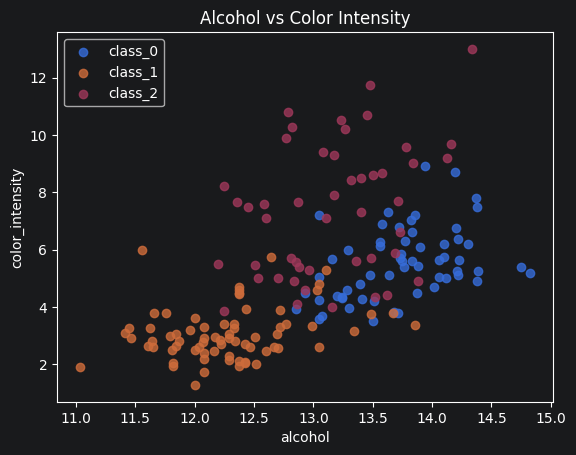

In [4]:
for cls, grp in df.groupby('WineClass'):
    plt.scatter(grp['alcohol'], grp['color_intensity'], label=cls, alpha=0.8)

plt.title('Alcohol vs Color Intensity')
plt.xlabel('alcohol')
plt.ylabel('color_intensity')
plt.legend()

plt.show()

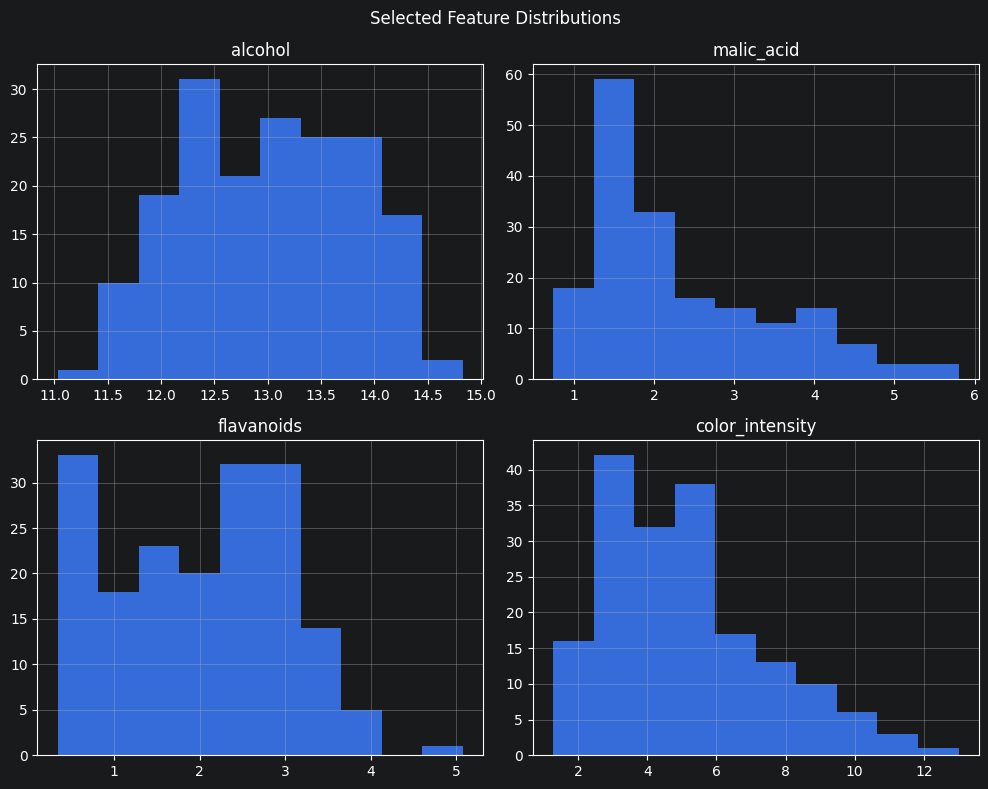

In [5]:
df[['alcohol', 'malic_acid', 'flavanoids', 'color_intensity']].hist(figsize=(10, 8))

plt.suptitle('Selected Feature Distributions')
plt.tight_layout()

plt.show()

In [6]:
feature_cols = [
    'alcohol',
    'malic_acid',
    'flavanoids',
    'color_intensity',
    'od280/od315_of_diluted_wines',
    'proline'
]

X = df[feature_cols]
y = df['WineClass']

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(X)

print('Missing values handled successfully.')
print('Feature matrix shape:', X.shape)

Missing values handled successfully.
Feature matrix shape: (178, 6)


In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print('Encoded classes:')
for idx, label in enumerate(label_encoder.classes_):
    print(f'{idx} -> {label}')

Encoded classes:
0 -> class_0
1 -> class_1
2 -> class_2


In [8]:
selected_features = [
    'alcohol',
    'malic_acid',
    'flavanoids',
    'color_intensity',
    'od280/od315_of_diluted_wines',
    'proline'
]

print('Selected Features:')
for col in selected_features:
    print('-', col)

Selected Features:
- alcohol
- malic_acid
- flavanoids
- color_intensity
- od280/od315_of_diluted_wines
- proline


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (142, 6)
Testing set size: (36, 6)


In [10]:
model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Predictions:')
print(y_pred[:10])

Predictions:
[0 2 0 1 1 0 0 0 1 2]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print('Accuracy:', accuracy)

print('\nConfusion Matrix:\n', cm)

print('\nClassification Report:\n', report)

Accuracy: 0.9722222222222222

Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



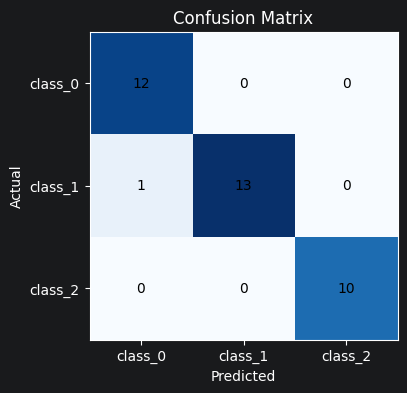

In [15]:
plt.figure(figsize=(6, 4))

plt.imshow(cm, cmap='Blues')

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='black')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.show()